# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import os
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import getpass
import ipywidgets as widgets
from IPython.display import display
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 31.0 MB/s eta 0:00:00


In [21]:
try:
    import pmdarima as pm
    from pmdarima.arima.utils import ndiffs, nsdiffs
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print('pmdarima no instalado: se usara grid search propio')

In [6]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

fatal: destination path 'proyecto_ciencia_datos' already exists and is not an empty directory.


In [7]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# DISEÑO DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


In [8]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,fecha,grupo,producto,mercado,departamento,codigo_departamento,municipio,codigo_municipio,precio_promedio_kg,circulacion
0,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, barranquillita",atlantico,8,barranquilla,8001,3073.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"ibague, plaza la 21",tolima,73,ibague,73001,4307.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"medellin, plaza minorista ""jose maria villa""",antioquia,5,medellin,5001,3717.0,si
...,...,...,...,...,...,...,...,...,...,...
749048,2026-06-01,frutas,manzana royal gala importada,"neiva, surabastos",huila,41,neiva,41001,8706.0,si
749049,2026-06-01,frutas,manzana royal gala importada,"monteria, mercado del sur",cordoba,23,monteria,23001,8573.0,si
749050,2026-06-01,frutas,manzana royal gala importada,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,7517.0,si
749051,2026-06-01,frutas,naranja valencia,"valledupar, mercabastos",cesar,20,valledupar,20001,2494.0,si


## Entrenar el Modelo

In [9]:
departamentos_2026 = sorted(
    df.loc[df["fecha"].dt.year == 2026, "departamento"]
      .dropna()
      .unique()
)
departamentos_2026

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [10]:
departamentos = ['colombia'] + departamentos_2026

In [78]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('colombia', 'antioquia', 'arauca'…

In [79]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: quindio


In [80]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["municipio"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    display(dropdown_municipio)

else:
    print("No es necesario seleccionar un municipio.")

Dropdown(description='Municipio:', layout=Layout(width='400px'), options=('armenia',), style=DescriptionStyle(…

In [81]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

Municipio seleccionado: armenia


In [82]:
if departamento.lower() == 'colombia':

    mercados = sorted(
        df[df["fecha"].dt.year == 2026]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

elif departamento.lower() == 'bogota, d.c.':

    mercados = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

else:

    municipio = dropdown_municipio.value

    mercados = sorted(
        df[
            (df["municipio"] == municipio) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

dropdown_mercado = widgets.Dropdown(
    options=mercados,
    description='Mercado:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_mercado)

Dropdown(description='Mercado:', layout=Layout(width='400px'), options=('armenia, mercar', 'armenia, retiro'),…

In [91]:
mercado = dropdown_mercado.value
print("Mercado seleccionado:", mercado)

Mercado seleccionado: armenia, mercar


In [92]:
mercado = dropdown_mercado.value

productos = sorted(
    df[
        (df["mercado"] == mercado) &
        (df["fecha"].dt.year == 2026)
    ]["producto"]
    .dropna()
    .unique()
    .tolist()
)

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('aceite de palma', 'aceite vegetal me…

In [93]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: breva


## Inicio del Modelo - Hacer Pruebas

# Fase 1: creacion de la serie

In [94]:
def preparar_serie(df, mercado, producto):
    serie = (
        df[
            (df['mercado'] == mercado) &
            (df['producto'] == producto)
        ][['fecha', 'precio_promedio_kg']]
        .copy()
    )
    serie = serie.sort_values('fecha')
    serie.set_index('fecha', inplace=True)

    serie.rename(
        columns={'precio_promedio_kg': 'precio'},
        inplace=True,
    )
    # Si hay varios registros en la misma fecha (p.ej. municipios), promediamos
    serie = serie.groupby(serie.index).mean()
    # Frecuencia mensual + relleno de huecos
    serie = serie.asfreq('MS').interpolate('linear').ffill().bfill()
    return serie['precio']
y = preparar_serie(df, mercado, producto)
y

,precio
fecha,
2013-11-01,3220.0
2013-12-01,5508.0
2014-01-01,4600.0
2014-02-01,2950.0
2014-03-01,2217.0
...,...
2025-09-01,9419.0
2025-10-01,9563.0
2025-11-01,9707.0


## Fase 1b — Verificación del tamaño de la serie
Antes de modelar, comprueba que la serie tenga suficientes observaciones. Reglas prácticas para SARIMA con estacionalidad mensual (m=12):

- **< 24 meses**: insuficiente — no se puede estimar componente estacional.
- **24–35 meses**: mínimo aceptable — modelo poco confiable, evita SARIMA (usa ARIMA no estacional).
- **36–47 meses**: aceptable — SARIMA viable pero con incertidumbre alta.
- **48–71 meses**: bueno — recomendado (≥ 4 ciclos estacionales).
- **≥ 72 meses**: óptimo (≥ 6 ciclos).

In [95]:
def fuerza_estacional(y, m=12):
    """Fs = max(0, 1 - Var(resid)/Var(resid+seasonal))  (Hyndman). >0.3 ~ estacionalidad util."""
    if len(y) < 2*m + 1:
        return np.nan
    try:
        res = STL(y, period=m, robust=True).fit()
    except Exception:
        return np.nan
    var_r  = np.nanvar(res.resid)
    var_rs = np.nanvar(res.resid + res.seasonal)
    return float(max(0.0, 1 - var_r/var_rs)) if var_rs > 0 else 0.0

def verificar_registros(y, m=12):
    n = int(y.dropna().shape[0])
    ciclos = n / m
    nivel = ('INSUFICIENTE' if n < 24 else 'MINIMO' if n < 36 else
             'ACEPTABLE' if n < 48 else 'BUENO' if n < 72 else 'OPTIMO')

    Fs = fuerza_estacional(y, m)
    ciclos_ok = n >= 3*m
    # FIX: la estacionalidad se usa solo si hay ciclos suficientes Y senal estacional real
    seasonal_ok = bool(ciclos_ok and np.isfinite(Fs) and Fs >= 0.30)
    seasonal_debil = bool(ciclos_ok and np.isfinite(Fs) and 0.15 <= Fs < 0.30)

    # presupuesto de parametros: ~1 por cada 10 observaciones
    presupuesto = max(2, n // 10)
    max_p = 3 if n >= 60 else 2 if n >= 36 else 1
    max_q = max_p
    max_P = 1 if seasonal_ok else 0
    max_Q = 1 if (seasonal_ok and n >= 4*m) else 0

    # horizonte de backtest: al menos 1 ciclo si alcanza, dejando train >= 3 ciclos
    h_bt = int(min(m, max(6, n // 5), max(3, n - max(3*m, 24))))

    info = dict(n=n, ciclos=round(ciclos,2), nivel=nivel, apto=n>=24, m=m,
                Fs=None if not np.isfinite(Fs) else round(Fs,3),
                seasonal_ok=seasonal_ok, seasonal_debil=seasonal_debil,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                presupuesto=presupuesto, h_bt=h_bt)

    print(f"Registros            : {n}")
    print(f"Ciclos (m={m})        : {ciclos:.2f}")
    print(f"Nivel                : {nivel}")
    print(f"Fuerza estacional Fs : {info['Fs']}  (>=0.30 usa SARIMA, <0.15 no aporta)")
    print(f"Componente estacional: {'SI' if seasonal_ok else 'NO -> ARIMA no estacional'}"
          + (' [debil]' if seasonal_debil else ''))
    print(f"Limites busqueda     : p<={max_p} q<={max_q} P<={max_P} Q<={max_Q} (max {presupuesto} params)")
    print(f"Horizonte backtest   : {h_bt} meses")
    if not info['apto']:
        print('ATENCION: serie insuficiente para modelar (<24).')
    return info
info = verificar_registros(y)


Registros            : 147
Ciclos (m=12)        : 12.25
Nivel                : OPTIMO
Fuerza estacional Fs : 0.36  (>=0.30 usa SARIMA, <0.15 no aporta)
Componente estacional: SI
Limites busqueda     : p<=3 q<=3 P<=1 Q<=1 (max 14 params)
Horizonte backtest   : 12 meses


#Fase 3: EDA express y especifico

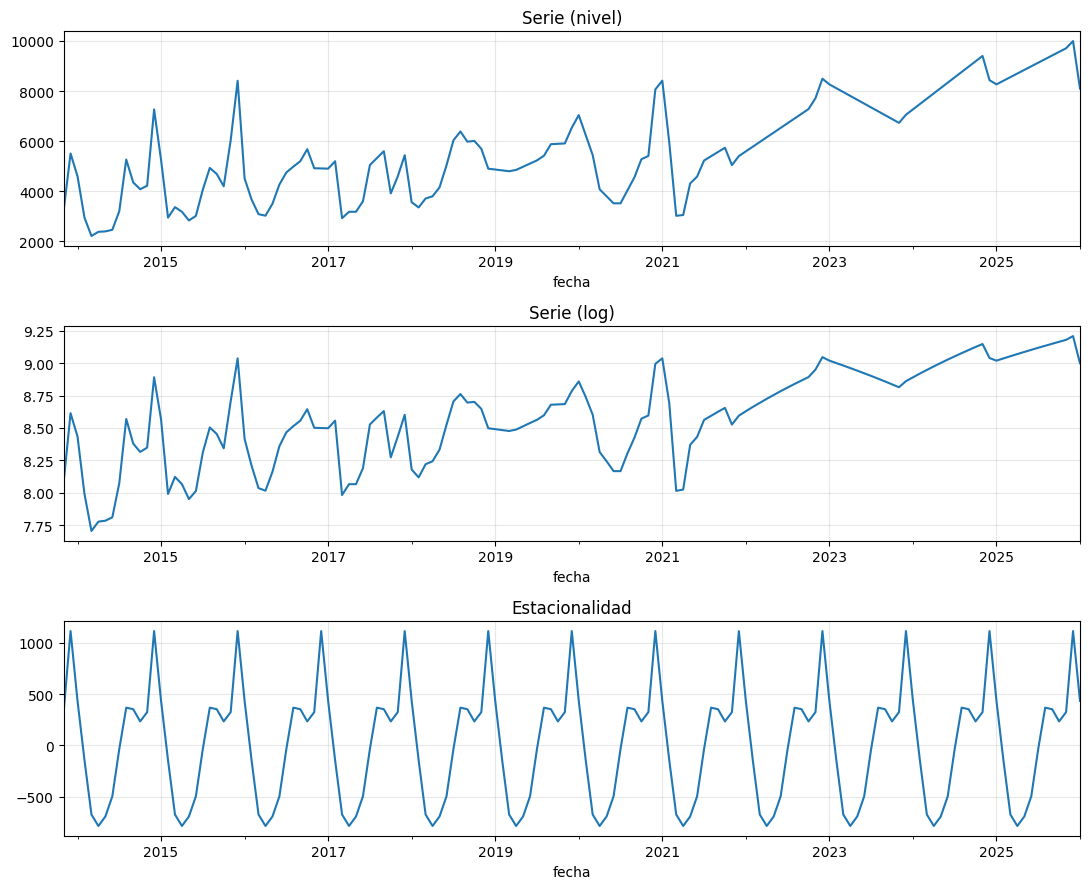

Amplitud estacional = 1,902.4 (33.1% del nivel medio)


In [96]:
M=12
fig, ax = plt.subplots(3,1, figsize=(11,9))
y.plot(ax=ax[0], title='Serie (nivel)'); ax[0].grid(alpha=.3)
np.log(y).plot(ax=ax[1], title='Serie (log)'); ax[1].grid(alpha=.3)
if len(y) >= 2*M:
    seasonal_decompose(y, model='additive', period=M).seasonal.plot(ax=ax[2], title='Estacionalidad')
    ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Amplitud estacional relativa: si es <5% del nivel, la estacionalidad casi no mueve el pronostico
if len(y) >= 2*M:
    est = seasonal_decompose(y, model='additive', period=M).seasonal
    print(f'Amplitud estacional = {est.max()-est.min():,.1f} '
          f'({(est.max()-est.min())/y.mean()*100:.1f}% del nivel medio)')

## Fase 3 — Estacionariedad y diferenciación

In [97]:
def test_estacionariedad(x, nombre=''):
    x = pd.Series(x).dropna()
    if len(x) < 8:
        print(f'{nombre}: muestra insuficiente ({len(x)})'); return None, None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        adf = adfuller(x)[1]
        kps = kpss(x, nlags='auto')[1]
    print(f'{nombre}: ADF p={adf:.3f}  KPSS p={kps:.3f}')
    return adf, kps

USE_LOG = True                      # estabiliza varianza; exige y > 0
y_mod_full = np.log(y) if USE_LOG else y.copy()

test_estacionariedad(y_mod_full, 'nivel')
test_estacionariedad(y_mod_full.diff(), 'd=1')

def estimar_dD(ys, info, m=12):
    """FIX: d y D se ESTIMAN, no se imponen. D solo si hay senal estacional real."""
    if HAS_PMDARIMA:
        d = int(min(2, ndiffs(ys, test='kpss', max_d=2)))
    else:
        d = 0 if test_estacionariedad(ys, '_')[0] < 0.05 else 1
    D = 0
    if info['seasonal_ok'] and len(ys) >= 3*m + m:
        if HAS_PMDARIMA:
            try:
                D = int(min(1, nsdiffs(ys, m=m, max_D=1, test='ocsb')))
            except Exception:
                D = 0
        else:
            D = 1
        # guarda: D=1 nunca debe dejar menos de 2 ciclos utiles
        if len(ys) - D*m - d < 2*m:
            D = 0
    print(f'Diferenciacion estimada -> d={d}, D={D} (m={m})')
    return d, D

D_ORDER, D_SEAS = estimar_dD(y_mod_full, info, M)


nivel: ADF p=0.862  KPSS p=0.010
d=1: ADF p=0.000  KPSS p=0.100
Diferenciacion estimada -> d=1, D=0 (m=12)


## Fase 4 — Identificación (ACF/PACF)

n efectivo tras diferenciar = 146 | lags = 36


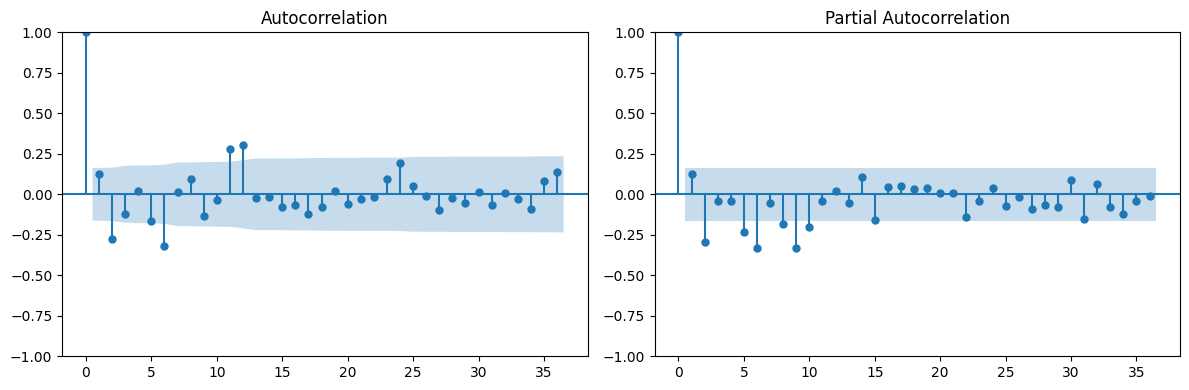

ACF(lag 12) = 0.340


In [98]:
yd = y_mod_full.copy()
for _ in range(D_ORDER): yd = yd.diff()
for _ in range(D_SEAS):  yd = yd.diff(M)
yd = yd.dropna()

n = len(yd)
lags = max(4, min(36, (n // 2) - 1))
print(f'n efectivo tras diferenciar = {n} | lags = {lags}')
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(yd, lags=lags, ax=ax[0]); plot_pacf(yd, lags=lags, method='ywm', ax=ax[1])
plt.tight_layout(); plt.show()

# Senal de sobre-diferenciacion estacional: ACF(m) fuertemente negativa
if len(yd) > M:
    acf_m = pd.Series(yd).autocorr(lag=M)
    print(f'ACF(lag {M}) = {acf_m:.3f}' + ('  <-- posible SOBRE-diferenciacion estacional (revisa D)' if acf_m < -0.35 else ''))


## Fase 5 — Estimación (auto_arima / grid AIC)

In [99]:
FIT_KW = dict(enforce_stationarity=True, enforce_invertibility=True)  # <-- FIX CENTRAL

def _fit(ys, order, sorder):
    return SARIMAX(ys, order=order, seasonal_order=sorder, **FIT_KW).fit(disp=False)

def modelo_estable(fit):
    """True si todas las raices AR (y estacionales) estan fuera del circulo unitario."""
    try:
        ar = np.concatenate([np.atleast_1d(fit.arroots), np.atleast_1d(getattr(fit,'seasonalarroots',[]))])
        return bool(len(ar) == 0 or np.all(np.abs(ar) > 1.01))
    except Exception:
        return True

def ajustar_sarima(ys, info, d, D, m=12, verbose=True):
    """ys ya viene en la escala de modelado (log si USE_LOG)."""
    seasonal = info['seasonal_ok'] and (D > 0 or info['max_P'] + info['max_Q'] > 0)
    max_p, max_q = info['max_p'], info['max_q']
    max_P = info['max_P'] if seasonal else 0
    max_Q = info['max_Q'] if seasonal else 0

    order, sorder = (1, d, 0), ((1, D, 0, m) if seasonal else (0, 0, 0, 0))
    if HAS_PMDARIMA:
        try:
            mdl = pm.auto_arima(ys, seasonal=seasonal, m=m if seasonal else 1,
                                d=d, D=D if seasonal else 0,
                                start_p=0, start_q=0, start_P=0, start_Q=0,
                                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                                information_criterion='aicc',   # AICc: penaliza mejor con n chico
                                stationary=False, stepwise=True,
                                suppress_warnings=True, error_action='ignore', trace=False)
            order, sorder = mdl.order, (mdl.seasonal_order if seasonal else (0,0,0,0))
        except Exception as e:
            if verbose: print('auto_arima fallo, uso fallback:', e)
    else:
        mejor, best = None, np.inf
        for p in range(max_p+1):
            for q in range(max_q+1):
                for P in range(max_P+1):
                    for Q in range(max_Q+1):
                        try:
                            f = _fit(ys, (p,d,q), (P,D,Q,m) if seasonal else (0,0,0,0))
                            if f.aicc < best and modelo_estable(f):
                                best, mejor = f.aicc, ((p,d,q), (P,D,Q,m) if seasonal else (0,0,0,0))
                        except Exception:
                            continue
        if mejor: order, sorder = mejor

    # presupuesto de parametros
    k = order[0] + order[2] + sorder[0] + sorder[2]
    if k > info['presupuesto']:
        if verbose: print(f'Modelo simplificado: k={k} > presupuesto={info["presupuesto"]}')
        order  = (1, d, 0)
        sorder = (1, D, 0, m) if seasonal else (0, 0, 0, 0)

    # verificacion de estabilidad; si no, degradar
    try:
        if not modelo_estable(_fit(ys, order, sorder)):
            if verbose: print('Modelo inestable -> degradado a (0,d,1)')
            order  = (0, d, 1)
            sorder = (0, D, 1, m) if seasonal else (0, 0, 0, 0)
    except Exception:
        order, sorder = (0, d, 1), (0, 0, 0, 0)
    return order, sorder

order, seasonal_order = ajustar_sarima(y_mod_full, info, D_ORDER, D_SEAS, M)
print('order =', order, '| seasonal_order =', seasonal_order, '| use_log =', USE_LOG)


Modelo inestable -> degradado a (0,d,1)
order = (0, 1, 1) | seasonal_order = (0, 0, 1, 12) | use_log = True


## Fase 6 — Diagnóstico de residuos

                                     SARIMAX Results                                      
Dep. Variable:                             precio   No. Observations:                  147
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 12)   Log Likelihood                  48.503
Date:                            Fri, 31 Jul 2026   AIC                            -91.006
Time:                                    21:07:06   BIC                            -82.055
Sample:                                11-01-2013   HQIC                           -87.369
                                     - 01-01-2026                                         
Covariance Type:                              opg                                         
Modelo estable (raices AR fuera del circulo): True
residuos utiles = 146 | lags diagnostico = 24


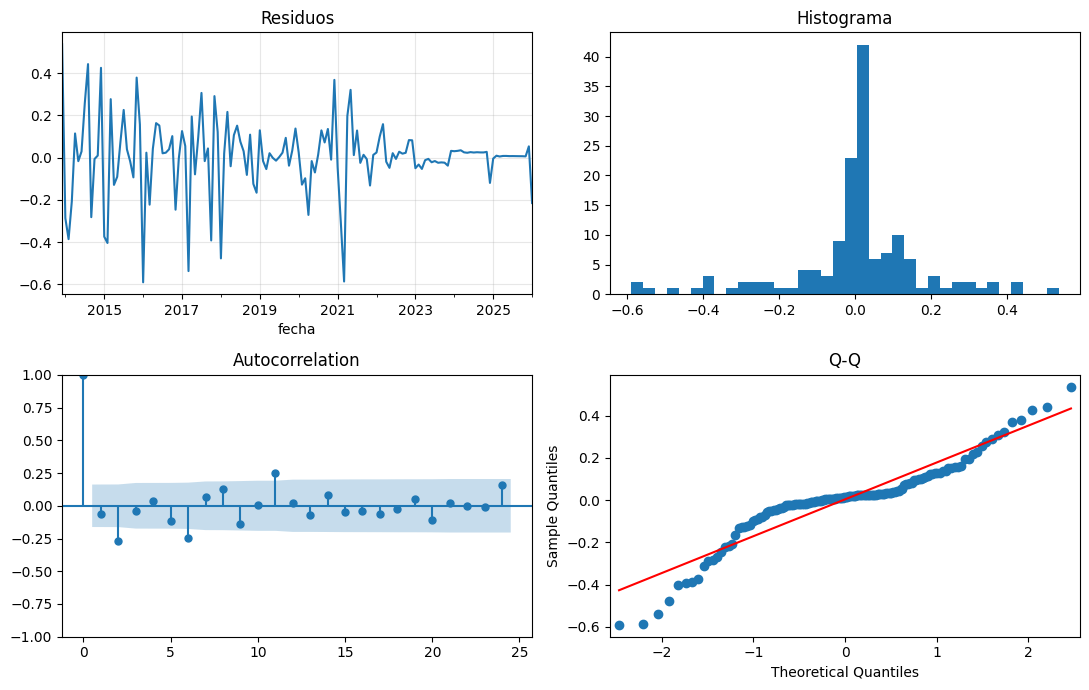

     lb_stat  lb_pvalue
10  30.02459   0.000849
Ruido blanco (p>0.05): False
Jarque-Bera p = 0.0


In [100]:
fit = _fit(y_mod_full, order, seasonal_order)
print(fit.summary().tables[0])
print('Modelo estable (raices AR fuera del circulo):', modelo_estable(fit))

resid = pd.Series(fit.resid).replace([np.inf,-np.inf], np.nan).dropna()
burn = order[1] + seasonal_order[1]*(seasonal_order[3] or 0)
resid = resid.iloc[burn:]
nr = len(resid)
lags_r = max(2, min(24, (nr // 2) - 1))
print(f'residuos utiles = {nr} | lags diagnostico = {lags_r}')

if nr >= 8:
    fig, ax = plt.subplots(2,2, figsize=(11,7))
    resid.plot(ax=ax[0,0], title='Residuos'); ax[0,0].grid(alpha=.3)
    ax[0,1].hist(resid, bins=max(5, nr//4)); ax[0,1].set_title('Histograma')
    plot_acf(resid, lags=lags_r, ax=ax[1,0])
    qqplot(resid, line='s', ax=ax[1,1]); ax[1,1].set_title('Q-Q')
    plt.tight_layout(); plt.show()
    lb = acorr_ljungbox(resid, lags=[max(1, min(lags_r, 10))], return_df=True)
    print(lb)
    print('Ruido blanco (p>0.05):', bool(lb['lb_pvalue'].iloc[0] > 0.05))
    print('Jarque-Bera p =', round(stats.jarque_bera(resid)[1], 4))
else:
    print('Muy pocos residuos para diagnostico grafico.')


## Fase 7 — Validación (backtest walk-forward + sMAPE / MASE)

In [101]:
def _metricas(y_true, y_pred, y_train_orig, m=12):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    mae   = np.mean(np.abs(y_true - y_pred))
    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    mape  = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    smape = np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred))) * 100
    yt = np.asarray(y_train_orig, float)
    lag = m if len(yt) > m + 2 else 1
    denom = np.mean(np.abs(yt[lag:] - yt[:-lag])) if len(yt) > lag else np.nan
    mase = mae/denom if denom and denom > 0 else np.nan
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, MASE=mase)

MAX_SIGMA = 4.0   # tolerancia del guardarrail en escala de modelado

def _pred_1paso(y_train, order, sorder, use_log):
    ym = np.log(y_train) if use_log else y_train
    f = SARIMAX(ym, order=order, seasonal_order=sorder, **FIT_KW).fit(disp=False)
    mu = float(f.get_forecast(steps=1).predicted_mean.iloc[0])
    # GUARDARRAIL: desviacion vs ultimo nivel, medida en sigmas de la serie diferenciada
    sigma = float(np.nanstd(np.diff(ym.values))) or 1e-6
    if not np.isfinite(mu) or abs(mu - float(ym.iloc[-1])) > MAX_SIGMA * sigma:
        raise ValueError(f'pronostico fuera de rango plausible (mu={mu:.3f})')
    return float(np.exp(mu)) if use_log else mu

def _fallback_1paso(y_train, use_log, m=12):
    ym = np.log(y_train) if use_log else y_train
    f = SARIMAX(ym, order=(0,1,1), seasonal_order=(0,0,0,0), **FIT_KW).fit(disp=False)
    mu = float(f.get_forecast(steps=1).predicted_mean.iloc[0])
    return float(np.exp(mu)) if use_log else mu

def backtest_wf(y, info, order, sorder, use_log=True, h=None, m=12,
                min_train=None, reselect=False):
    n = len(y)
    h = int(h or info['h_bt'])
    min_train = min_train or max(3*m, 24)
    h = int(min(h, max(1, n - min_train)))
    start = n - h
    preds, reales, idx, degradados = [], [], [], 0

    for i in range(h):
        y_train = y.iloc[:start+i]
        o, so = order, sorder
        if reselect:   # <-- elimina el leakage de elegir el modelo con datos futuros
            ym = np.log(y_train) if use_log else y_train
            inf_i = dict(info); inf_i['n'] = len(y_train)
            d_i, D_i = estimar_dD(ym, inf_i, m)
            o, so = ajustar_sarima(ym, inf_i, d_i, D_i, m, verbose=False)
        try:
            p = _pred_1paso(y_train, o, so, use_log)
        except Exception as e:
            degradados += 1
            try:
                p = _fallback_1paso(y_train, use_log, m)
            except Exception:
                p = float(y_train.iloc[-1])
        preds.append(p); reales.append(float(y.iloc[start+i])); idx.append(y.index[start+i])

    print(f'backtest walk-forward: h={h}, train inicial={start}, pasos degradados={degradados}')
    return _metricas(reales, preds, y.iloc[:start], m=m), reales, preds, idx

def baselines(y, h, m=12):
    n = len(y); start = n - h
    reales = y.iloc[start:].values.astype(float)
    naive  = y.shift(1).iloc[start:].values.astype(float)
    snaive = y.shift(m).iloc[start:].values.astype(float)
    drift  = np.array([float(y.iloc[start+i-1] + (y.iloc[start+i-1]-y.iloc[0])/(start+i-1))
                       for i in range(h)])
    out = {}
    for nom, p in [('Naive', naive), ('Naive estacional', snaive), ('Drift', drift)]:
        if np.isnan(p).any(): continue
        out[nom] = _metricas(reales, p, y.iloc[:start], m=m)
    return out

metrics, reales, preds, idx = backtest_wf(y, info, order, seasonal_order,
                                          use_log=USE_LOG, h=info['h_bt'], m=M,
                                          reselect=False)   # pon True para validacion honesta
print('\n--- SARIMA ---')
for k,v in metrics.items(): print(f'{k:6} = {v:.3f}')

print('\n--- Baselines ---')
bl = baselines(y, len(idx), M)
tabla = pd.DataFrame({'SARIMA': metrics, **bl}).T[['MAE','RMSE','MAPE','sMAPE','MASE']]
print(tabla.round(3))

mejor = tabla['MAE'].idxmin()
print(f'\nMejor por MAE: {mejor}')
if mejor != 'SARIMA':
    print('AVISO: el SARIMA no supera al baseline. Usa el baseline o revisa especificacion.')


backtest walk-forward: h=12, train inicial=135, pasos degradados=0

--- SARIMA ---
MAE    = 260.566
RMSE   = 583.849
MAPE   = 3.045
sMAPE  = 2.845
MASE   = 0.236

--- Baselines ---
                      MAE     RMSE   MAPE  sMAPE   MASE
SARIMA            260.566  583.849  3.045  2.845  0.236
Naive             301.750  568.402  3.515  3.325  0.273
Naive estacional  659.015  745.726  7.254  7.600  0.597
Drift             267.660  572.342  3.148  2.942  0.242

Mejor por MAE: SARIMA


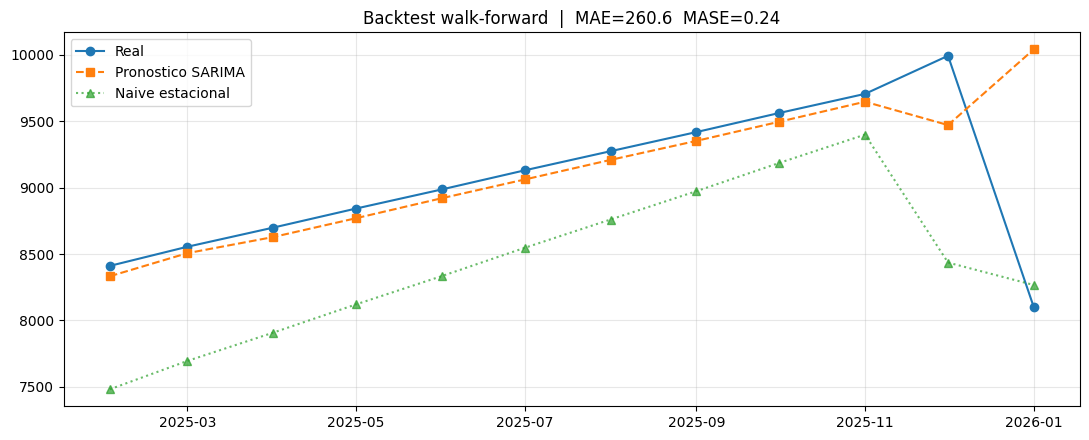

Pronosticos fuera del rango plausible: ninguno OK


In [102]:
plt.figure(figsize=(11,4.5))
plt.plot(idx, reales, 'o-', label='Real')
plt.plot(idx, preds,  's--', label='Pronostico SARIMA')
if len(y) > M:
    plt.plot(idx, y.shift(M).loc[idx].values, '^:', alpha=.7, label='Naive estacional')
plt.title(f'Backtest walk-forward  |  MAE={metrics["MAE"]:,.1f}  MASE={metrics["MASE"]:.2f}')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Escala automatica y control: ningun punto debe salirse del rango historico ampliado
lo_h, hi_h = y.min()*0.5, y.max()*2.0
fuera = [(t, p) for t, p in zip(idx, preds) if not (lo_h <= p <= hi_h)]
print('Pronosticos fuera del rango plausible:', fuera if fuera else 'ninguno OK')

## Fase 8 — Pronóstico final

In [103]:
def pronosticar(y, order, sorder, use_log=True, steps=6, alpha=0.05, m=12):
    ym = np.log(y) if use_log else y
    fit = SARIMAX(ym, order=order, seasonal_order=sorder, **FIT_KW).fit(disp=False)
    if not modelo_estable(fit):
        print('AVISO: modelo inestable, degradando a (0,1,1)')
        order, sorder = (0,1,1), (0,0,0,0)
        fit = SARIMAX(ym, order=order, seasonal_order=sorder, **FIT_KW).fit(disp=False)

    fc   = fit.get_forecast(steps=steps)
    mu   = fc.predicted_mean
    ci   = fc.conf_int(alpha=alpha)
    var  = fc.var_pred_mean

    if use_log:
        mediana = np.exp(mu)
        media   = np.exp(mu + var/2.0)
        ci      = np.exp(ci)
    else:
        mediana = mu; media = mu

    # Guardarrail final
    lo_h, hi_h = y.min()*0.4, y.max()*2.5
    if not ((mediana >= lo_h) & (mediana <= hi_h)).all():
        print(f'AVISO: pronostico fuera del rango historico [{lo_h:,.0f} ; {hi_h:,.0f}] -> revisar modelo')
    return mediana.rename('pred_mediana'), media.rename('pred_media'), ci, fit

pred, pred_media, ci, fit_full = pronosticar(y, order, seasonal_order,
                                             use_log=USE_LOG, steps=6, m=M)
print(pd.concat([pred, pred_media, ci], axis=1).round(2))

# Amplitud relativa del IC: si es enorme, el modelo no esta informando
amp = (ci.iloc[:,1] - ci.iloc[:,0]) / pred
print('\nAmplitud IC95 / punto:', amp.round(2).to_dict())
if amp.iloc[0] > 1.5:
    print('AVISO: IC muy ancho (>150% del punto). Serie con mucha varianza o modelo mal especificado.')



            pred_mediana  pred_media  lower precio  upper precio
2026-02-01       7765.06     7882.36       5530.26      10902.94
2026-03-01       7778.32     8069.81       4570.79      13236.71
2026-04-01       7794.80     8265.12       3985.04      15246.76
2026-05-01       7812.45     8466.38       3560.33      17142.90
2026-06-01       7828.59     8670.83       3227.65      18988.10
2026-07-01       7844.80     8880.25       2956.14      20818.03

Amplitud IC95 / punto: {Timestamp('2026-02-01 00:00:00'): 0.69, Timestamp('2026-03-01 00:00:00'): 1.11, Timestamp('2026-04-01 00:00:00'): 1.44, Timestamp('2026-05-01 00:00:00'): 1.74, Timestamp('2026-06-01 00:00:00'): 2.01, Timestamp('2026-07-01 00:00:00'): 2.28}


## Fase 9 — Persistencia y monitoreo

In [104]:
joblib.dump({'fit': fit_full, 'order': order, 'seasonal_order': seasonal_order,
             'use_log': USE_LOG, 'm': M, 'info': info, 'metrics': metrics},
            'sarima_model.pkl')
print('modelo guardado')

modelo guardado


## Fase 10: Validación: naive estacional + factor histórico del mes objetivo

In [105]:
naive_next = float(y.iloc[-M]) if len(y) > M else float(y.iloc[-1])
print(f'Naive estacional (mismo mes ano pasado): {naive_next:,.2f}')

mes_obj = (y.index[-1] + pd.offsets.MonthBegin(1)).month
hist = y[y.index.month == mes_obj]
if len(hist):
    print(f'Historico mes {mes_obj}: n={len(hist)} media={hist.mean():,.2f} '
          f'rango=[{hist.min():,.2f} ; {hist.max():,.2f}]')
    # factor estacional historico: cuanto sube/baja ese mes respecto al mes previo
    ratios = [y.iloc[i]/y.iloc[i-1] for i in range(1, len(y)) if y.index[i].month == mes_obj]
    if ratios:
        print(f'Variacion historica mes {mes_obj} vs mes previo: {np.median(ratios)*100-100:+.1f}% (mediana)')


Naive estacional (mismo mes ano pasado): 8,411.00
Historico mes 2: n=12 media=5,411.72 rango=[2,950.00 ; 8,411.00]
Variacion historica mes 2 vs mes previo: -3.8% (mediana)


##Fase 11: Resumen de serie


In [106]:
def resumen(y, metrics, tabla, pred, ci, naive_next):
    prox = pred.index[0].strftime('%Y-%m')
    print('='*60)
    print('RESUMEN DE RESULTADOS')
    print('='*60)
    print('Metricas backtest (SARIMA vs baselines):')
    print(tabla.round(3).to_string())
    print('-'*60)
    print(f'Ultimo mes observado ({y.index[-1].strftime("%Y-%m")}): {y.iloc[-1]:,.2f}')
    print(f'Promedio ultimos 3 meses:        {y.tail(3).mean():,.2f}')
    print(f'Naive estacional (referencia):   {naive_next:,.2f}')
    print(f'Pronostico SARIMA ({prox}):      {pred.iloc[0]:,.2f}')
    lo, hi = float(ci.iloc[0,0]), float(ci.iloc[0,1])
    print(f'  Intervalo 95%: [{lo:,.2f} ; {hi:,.2f}]')
    print(f'  Punto dentro del IC: {lo <= pred.iloc[0] <= hi}')
    var = (pred.iloc[0]/y.iloc[-1]-1)*100
    flag = '  <-- SALTO SOSPECHOSO' if abs(var) > 25 else ''
    print(f'  Variacion vs ultimo mes: {var:+.1f}%{flag}')
    print('-'*60)
    print('Interpretacion MASE:  <1 mejor que naive estacional | >1 peor')
    m_ = metrics['MASE']
    print(f'  MASE = {m_:.2f} -> ' + ('el modelo APORTA' if m_ < 1 else 'el modelo NO supera al naive'))
    print('='*60)

resumen(y, metrics, tabla, pred, ci, naive_next)


RESUMEN DE RESULTADOS
Metricas backtest (SARIMA vs baselines):
                      MAE     RMSE   MAPE  sMAPE   MASE
SARIMA            260.566  583.849  3.045  2.845  0.236
Naive             301.750  568.402  3.515  3.325  0.273
Naive estacional  659.015  745.726  7.254  7.600  0.597
Drift             267.660  572.342  3.148  2.942  0.242
------------------------------------------------------------
Ultimo mes observado (2026-01): 8,100.00
Promedio ultimos 3 meses:        9,267.00
Naive estacional (referencia):   8,411.00
Pronostico SARIMA (2026-02):      7,765.06
  Intervalo 95%: [5,530.26 ; 10,902.94]
  Punto dentro del IC: True
  Variacion vs ultimo mes: -4.1%
------------------------------------------------------------
Interpretacion MASE:  <1 mejor que naive estacional | >1 peor
  MASE = 0.24 -> el modelo APORTA


#Fase 12: Comparacion de resultados y prediccion a 12 meses

In [107]:
H_FUTURO = 12          # meses a pronosticar
H_BT     = int(info['h_bt'])   # pasos de backtest (mismos para todos los candidatos)

# ---------- predictores de 1 paso (todos reciben y_train en NIVEL y devuelven nivel) ----------
def p_sarima(y_train, order, sorder):
    return _pred_1paso(y_train, order, sorder, USE_LOG)

def p_ets(y_train, seasonal):
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    ym = np.log(y_train) if USE_LOG else y_train
    kw = dict(trend='add', damped_trend=True, initialization_method='estimated')
    if seasonal and len(ym) >= 2*M + 4:
        kw.update(seasonal='add', seasonal_periods=M)
    f = ExponentialSmoothing(ym, **kw).fit(optimized=True)
    mu = float(f.forecast(1).iloc[0])
    sigma = float(np.nanstd(np.diff(np.asarray(ym, float)))) or 1e-6
    if not np.isfinite(mu) or abs(mu - float(ym.iloc[-1])) > MAX_SIGMA * sigma:
        raise ValueError('ETS fuera de rango')
    return float(np.exp(mu)) if USE_LOG else mu

def backtest_generico(y, predictor, h, m=12, nombre=''):
    """Walk-forward de 1 paso con la MISMA ventana de test para todos los candidatos."""
    n = len(y); start = n - h
    preds, reales, idx, degradados = [], [], [], 0
    for i in range(h):
        y_train = y.iloc[:start+i]
        try:
            p = float(predictor(y_train))
            if not np.isfinite(p):
                raise ValueError('no finito')
        except Exception:
            degradados += 1
            p = float(y_train.iloc[-1])          # fallback naive
        preds.append(p); reales.append(float(y.iloc[start+i])); idx.append(y.index[start+i])
    met = _metricas(reales, preds, y.iloc[:start], m=m)
    met['pasos_degradados'] = degradados
    return met, np.array(preds), np.array(reales), idx

# ---------- catalogo de candidatos ----------
order_ns = (order[0], order[1], order[2])                 # parte no estacional del ganador Fase 5
usa_estacional = bool(seasonal_order[3]) and (seasonal_order[0] or seasonal_order[1] or seasonal_order[2])

candidatos = {
    'SARIMA':                 lambda yt: p_sarima(yt, order, seasonal_order),
    'ARIMA (sin estacional)': lambda yt: p_sarima(yt, order_ns, (0,0,0,0)),
    'ARIMA(0,1,1)':           lambda yt: p_sarima(yt, (0,1,1), (0,0,0,0)),
    'ETS Holt-Winters':       lambda yt: p_ets(yt, seasonal=info['seasonal_ok']),
}
if not usa_estacional:
    candidatos.pop('ARIMA (sin estacional)')   # seria identico al SARIMA

filas, curvas = {}, {}
for nom, f in candidatos.items():
    met, pr, re_, ix = backtest_generico(y, f, H_BT, M, nom)
    filas[nom] = met; curvas[nom] = (ix, pr)
    print(f'{nom:24} MASE={met["MASE"]:.3f}  MAE={met["MAE"]:,.1f}  sMAPE={met["sMAPE"]:.1f}%  degradados={met["pasos_degradados"]}')

# baselines sobre la MISMA ventana
for nom, met in baselines(y, H_BT, M).items():
    met = dict(met); met['pasos_degradados'] = 0
    filas[nom] = met
    print(f'{nom:24} MASE={met["MASE"]:.3f}  MAE={met["MAE"]:,.1f}  sMAPE={met["sMAPE"]:.1f}%')

comparativa = pd.DataFrame(filas).T[['MAE','RMSE','MAPE','sMAPE','MASE','pasos_degradados']]
comparativa = comparativa.sort_values('MASE')
print('\n=== COMPARATIVA DE MODELOS (backtest walk-forward, h=%d) ===' % H_BT)
print(comparativa.round(3).to_string())


SARIMA                   MASE=0.236  MAE=260.6  sMAPE=2.8%  degradados=0
ARIMA (sin estacional)   MASE=0.253  MAE=279.5  sMAPE=3.1%  degradados=0
ARIMA(0,1,1)             MASE=0.253  MAE=279.5  sMAPE=3.1%  degradados=0
ETS Holt-Winters         MASE=0.626  MAE=691.0  sMAPE=7.9%  degradados=0
Naive                    MASE=0.273  MAE=301.8  sMAPE=3.3%
Naive estacional         MASE=0.597  MAE=659.0  sMAPE=7.6%
Drift                    MASE=0.242  MAE=267.7  sMAPE=2.9%

=== COMPARATIVA DE MODELOS (backtest walk-forward, h=12) ===
                            MAE     RMSE   MAPE  sMAPE   MASE  pasos_degradados
SARIMA                  260.566  583.849  3.045  2.845  0.236               0.0
Drift                   267.660  572.342  3.148  2.942  0.242               0.0
ARIMA(0,1,1)            279.460  581.495  3.280  3.070  0.253               0.0
ARIMA (sin estacional)  279.460  581.495  3.280  3.070  0.253               0.0
Naive                   301.750  568.402  3.515  3.325  0.273        

MEJOR MODELO: SARIMA   (MASE = 0.236)
MASE=0.236 -> Aporta valor claro sobre el naive estacional.
Segundo lugar: Drift (MASE=0.242) | ventaja del ganador: 2.7%


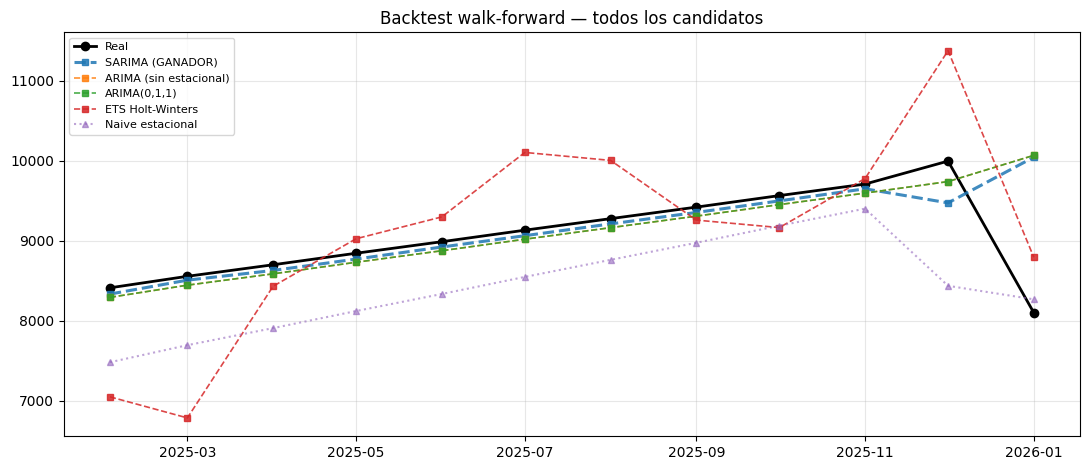

In [108]:
# ---------- eleccion del ganador ----------
crit = 'MASE' if comparativa['MASE'].notna().all() else 'MAE'
GANADOR = comparativa[crit].idxmin()
mase_g  = float(comparativa.loc[GANADOR, 'MASE'])

print('='*64)
print(f'MEJOR MODELO: {GANADOR}   ({crit} = {comparativa.loc[GANADOR, crit]:.3f})')
print('='*64)
if np.isfinite(mase_g):
    if mase_g < 0.8:   veredicto = 'Aporta valor claro sobre el naive estacional.'
    elif mase_g < 1.0: veredicto = 'Mejora marginal sobre el naive; util pero con poco margen.'
    else:              veredicto = 'NINGUN modelo supera al naive: usa el baseline y no sobre-modeles.'
    print(f'MASE={mase_g:.3f} -> {veredicto}')
segundo = comparativa.index[1]
print(f'Segundo lugar: {segundo} ({crit}={comparativa.loc[segundo, crit]:.3f}) | '
      f'ventaja del ganador: {(comparativa.loc[segundo, crit]/comparativa.loc[GANADOR, crit]-1)*100:.1f}%')

# grafico comparativo del backtest
plt.figure(figsize=(11,4.8))
ix0 = list(curvas.values())[0][0] if curvas else idx
plt.plot(ix0, y.loc[ix0].values, 'ko-', lw=2, label='Real')
for nom,(ix,pr) in curvas.items():
    plt.plot(ix, pr, '--', marker='s', ms=4, alpha=.85,
             lw=2.2 if nom==GANADOR else 1.2, label=nom + (' (GANADOR)' if nom==GANADOR else ''))
if len(y) > M:
    plt.plot(ix0, y.shift(M).loc[ix0].values, ':', marker='^', ms=4, alpha=.6, label='Naive estacional')
plt.title('Backtest walk-forward — todos los candidatos'); plt.legend(fontsize=8)
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [109]:
# ---------- pronostico de los proximos 12 meses con el GANADOR ----------
fut_idx = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=H_FUTURO, freq='MS')

def fc_sarima(o, so, steps):
    med, media, ci, f = pronosticar(y, o, so, use_log=USE_LOG, steps=steps, m=M)
    ci.columns = ['lo95','hi95']
    return med.values, ci['lo95'].values, ci['hi95'].values, f

def fc_ets(steps, seasonal):
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    ym = np.log(y) if USE_LOG else y
    kw = dict(trend='add', damped_trend=True, initialization_method='estimated')
    if seasonal and len(ym) >= 2*M + 4:
        kw.update(seasonal='add', seasonal_periods=M)
    f = ExponentialSmoothing(ym, **kw).fit(optimized=True)
    mu = f.forecast(steps)
    s = float(np.nanstd(f.resid)) if hasattr(f, 'resid') else float(np.nanstd(np.diff(ym)))
    se = s * np.sqrt(np.arange(1, steps+1))          # banda aproximada (random-walk-like)
    lo, hi = mu.values - 1.96*se, mu.values + 1.96*se
    return (np.exp(mu.values), np.exp(lo), np.exp(hi), f) if USE_LOG else (mu.values, lo, hi, f)

def fc_baseline(nombre, steps):
    ym = np.log(y) if USE_LOG else y
    if nombre == 'Naive':
        mu = np.repeat(float(ym.iloc[-1]), steps)
    elif nombre == 'Naive estacional':
        base = ym.iloc[-M:].values
        mu = np.array([base[i % M] for i in range(steps)])
    else:  # Drift
        pend = (float(ym.iloc[-1]) - float(ym.iloc[0])) / (len(ym)-1)
        mu = float(ym.iloc[-1]) + pend*np.arange(1, steps+1)
    s = float(np.nanstd(np.diff(np.asarray(ym, float)))) or 1e-6
    se = s*np.sqrt(np.arange(1, steps+1))
    lo, hi = mu - 1.96*se, mu + 1.96*se
    return (np.exp(mu), np.exp(lo), np.exp(hi), None) if USE_LOG else (mu, lo, hi, None)

if GANADOR == 'SARIMA':
    punto, lo, hi, modelo_final = fc_sarima(order, seasonal_order, H_FUTURO)
elif GANADOR == 'ARIMA (sin estacional)':
    punto, lo, hi, modelo_final = fc_sarima(order_ns, (0,0,0,0), H_FUTURO)
elif GANADOR == 'ARIMA(0,1,1)':
    punto, lo, hi, modelo_final = fc_sarima((0,1,1), (0,0,0,0), H_FUTURO)
elif GANADOR == 'ETS Holt-Winters':
    punto, lo, hi, modelo_final = fc_ets(H_FUTURO, seasonal=info['seasonal_ok'])
else:
    punto, lo, hi, modelo_final = fc_baseline(GANADOR, H_FUTURO)

forecast_12m = pd.DataFrame({'pred': punto, 'lo95': lo, 'hi95': hi}, index=fut_idx)
forecast_12m['var_%_vs_mes_previo'] = forecast_12m['pred'].pct_change().fillna(
    forecast_12m['pred'].iloc[0]/float(y.iloc[-1]) - 1) * 100
forecast_12m['amplitud_IC_%'] = (forecast_12m['hi95'] - forecast_12m['lo95']) / forecast_12m['pred'] * 100
forecast_12m.index.name = 'Mes'

# guardarrail final sobre los 12 pasos
lo_h, hi_h = y.min()*0.4, y.max()*2.5
fuera12 = forecast_12m[(forecast_12m['pred'] < lo_h) | (forecast_12m['pred'] > hi_h)]
print(f'PRONOSTICO {H_FUTURO} MESES  |  modelo: {GANADOR}')
print(forecast_12m.round(2).to_string())
print('\nFuera de rango plausible:', 'ninguno OK' if fuera12.empty else fuera12.index.strftime('%Y-%m').tolist())


PRONOSTICO 12 MESES  |  modelo: SARIMA
               pred     lo95      hi95  var_%_vs_mes_previo  amplitud_IC_%
Mes                                                                       
2026-02-01  7765.06  5530.26  10902.94                -4.14          69.19
2026-03-01  7778.32  4570.79  13236.71                 0.17         111.41
2026-04-01  7794.80  3985.04  15246.76                 0.21         144.48
2026-05-01  7812.45  3560.33  17142.90                 0.23         173.86
2026-06-01  7828.59  3227.65  18988.10                 0.21         201.32
2026-07-01  7844.80  2956.14  20818.03                 0.21         227.69
2026-08-01  7860.22  2727.88  22648.75                 0.20         253.44
2026-09-01  7875.48  2532.23  24493.54                 0.19         278.86
2026-10-01  7890.50  2361.89  26360.17                 0.19         304.14
2026-11-01  7904.03  2211.45  28250.05                 0.17         329.43
2026-12-01  8003.23  2100.13  30498.94                 1.26  

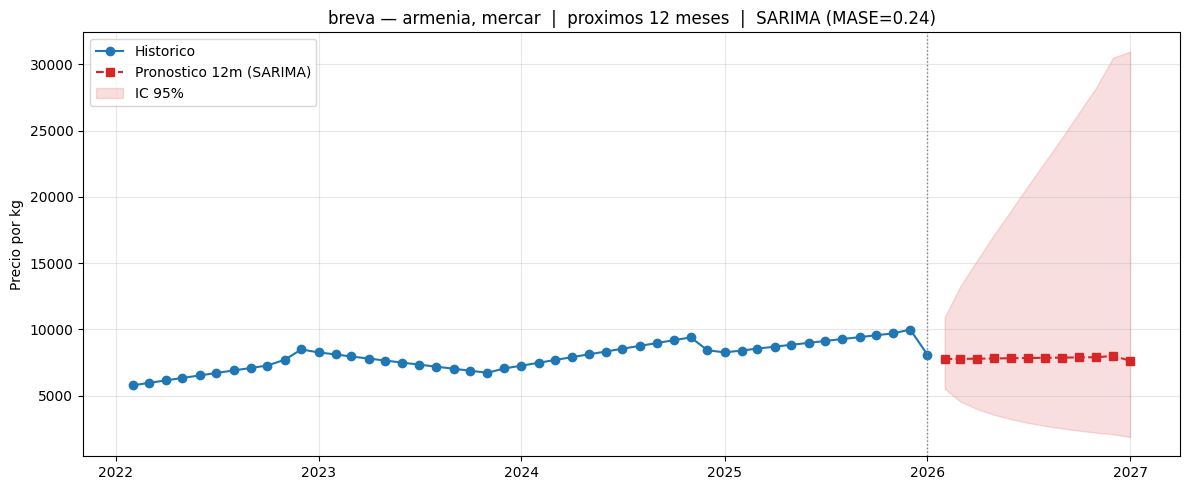

guardado: pronostico_12_meses.csv


In [112]:
plt.figure(figsize=(12,5))
hist_plot = y.iloc[-min(len(y), 48):]
plt.plot(hist_plot.index, hist_plot.values, 'o-', color='#1f77b4', label='Historico')
plt.plot(forecast_12m.index, forecast_12m['pred'], 's--', color='#d62728',
         label=f'Pronostico 12m ({GANADOR})')
plt.fill_between(forecast_12m.index, forecast_12m['lo95'], forecast_12m['hi95'],
                 color='#d62728', alpha=.15, label='IC 95%')
plt.axvline(y.index[-1], color='gray', ls=':', lw=1)
plt.title(f'{producto} — {mercado}  |  proximos {H_FUTURO} meses  |  {GANADOR} (MASE={mase_g:.2f})')
plt.ylabel('Precio por kg'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

forecast_12m.round(2).to_csv('pronostico_12_meses.csv')
print('guardado: pronostico_12_meses.csv')

#Fase 13: Conclusión final

In [114]:
print('='*70)
print('CONCLUSION FINAL')
print('='*70)
print(f'Serie          : {producto} en {mercado}  (n={len(y)} meses, {len(y)/M:.1f} ciclos)')
print(f'Estacionalidad : Fs={info["Fs"]:.2f} -> ' + ('usada' if info['seasonal_ok'] else 'NO usada (senal debil)'))
print(f'Modelo Fase 5  : SARIMA{order}x{seasonal_order}')
print(f'MEJOR MODELO   : {GANADOR}   (MASE={mase_g:.3f}, MAE={comparativa.loc[GANADOR,"MAE"]:,.1f}, sMAPE={comparativa.loc[GANADOR,"sMAPE"]:.1f}%)')
print(f'                 {veredicto}')
print('-'*70)
print(f'Ultimo observado {y.index[-1].strftime("%Y-%m")}: {y.iloc[-1]:,.2f}')
print(f'Pronostico {forecast_12m.index[0].strftime("%Y-%m")}: {forecast_12m["pred"].iloc[0]:,.2f} '
      f'[{forecast_12m["lo95"].iloc[0]:,.2f} ; {forecast_12m["hi95"].iloc[0]:,.2f}]')
print(f'Pronostico {forecast_12m.index[-1].strftime("%Y-%m")}: {forecast_12m["pred"].iloc[-1]:,.2f} '
      f'[{forecast_12m["lo95"].iloc[-1]:,.2f} ; {forecast_12m["hi95"].iloc[-1]:,.2f}]')
print(f'Variacion acumulada 12m: {(forecast_12m["pred"].iloc[-1]/float(y.iloc[-1])-1)*100:+.1f}%')
print(f'Mes mas alto : {forecast_12m["pred"].idxmax().strftime("%Y-%m")} ({forecast_12m["pred"].max():,.2f})')
print(f'Mes mas bajo : {forecast_12m["pred"].idxmin().strftime("%Y-%m")} ({forecast_12m["pred"].min():,.2f})')
print('='*70)
print('Ranking completo:')
print(comparativa[['MASE','MAE','sMAPE']].round(3).to_string())


CONCLUSION FINAL
Serie          : breva en armenia, mercar  (n=147 meses, 12.2 ciclos)
Estacionalidad : Fs=0.36 -> usada
Modelo Fase 5  : SARIMA(0, 1, 1)x(0, 0, 1, 12)
MEJOR MODELO   : SARIMA   (MASE=0.236, MAE=260.6, sMAPE=2.8%)
                 Aporta valor claro sobre el naive estacional.
----------------------------------------------------------------------
Ultimo observado 2026-01: 8,100.00
Pronostico 2026-02: 7,765.06 [5,530.26 ; 10,902.94]
Pronostico 2027-01: 7,641.80 [1,886.26 ; 30,959.16]
Variacion acumulada 12m: -5.7%
Mes mas alto : 2026-12 (8,003.23)
Mes mas bajo : 2027-01 (7,641.80)
Ranking completo:
                         MASE      MAE  sMAPE
SARIMA                  0.236  260.566  2.845
Drift                   0.242  267.660  2.942
ARIMA(0,1,1)            0.253  279.460  3.070
ARIMA (sin estacional)  0.253  279.460  3.070
Naive                   0.273  301.750  3.325
Naive estacional        0.597  659.015  7.600
ETS Holt-Winters        0.626  690.956  7.892


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
